* # LISTA 1

Nesta liste iremos explorar os métodos de analise descritiva de séries temporais.
    

* # Avaliando a Condição de Estacionariedade em Séries Temporais

**Índice Dow Jones:** O Dow Jones Industrial Average, Dow Jones, ou simplesmente Dow, é um índice do mercado de acções de 30 empresas importantes cotadas nas bolsas de valores dos Estados Unidos.

Dataset: indice_dowjones.csv

In [ ]:
#pip install kagglehub

In [5]:
import pandas as pd
df_dowjones = pd.read_csv('indice_dowjones.csv', index_col = 'Date')

df_dowjones

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
"Dec 31, 2019","28,538.44","28,414.64","28,547.35","28,376.49",193.34M,0.27%
"Dec 30, 2019","28,462.14","28,654.76","28,664.69","28,428.98",185.07M,-0.64%
"Dec 27, 2019","28,645.26","28,675.34","28,701.66","28,608.98",184.93M,0.08%
"Dec 26, 2019","28,621.39","28,539.46","28,624.10","28,535.15",155.97M,0.37%
"Dec 24, 2019","28,515.45","28,572.57","28,576.80","28,503.21",95.29M,-0.13%
...,...,...,...,...,...,...
"Jan 09, 2009","8,599.18","8,738.80","8,800.45","8,541.75",-,-1.64%
"Jan 08, 2009","8,742.46","8,769.94","8,807.14","8,593.52",-,-0.31%
"Jan 07, 2009","8,769.70","8,996.94","8,996.94","8,690.45",-,-2.72%


* ### Série Observada (Gráfico)

In [9]:
df_dowjones.dtypes
df_dowjones['Price'] = df_dowjones['Price'].astype(float)
df_dowjones.dtypes

ValueError: could not convert string to float: '28,538.44'

In [10]:
df_dowjones['Price'] = df_dowjones['Price'].str.replace(',', '').astype(float)

<Axes: xlabel='Date'>

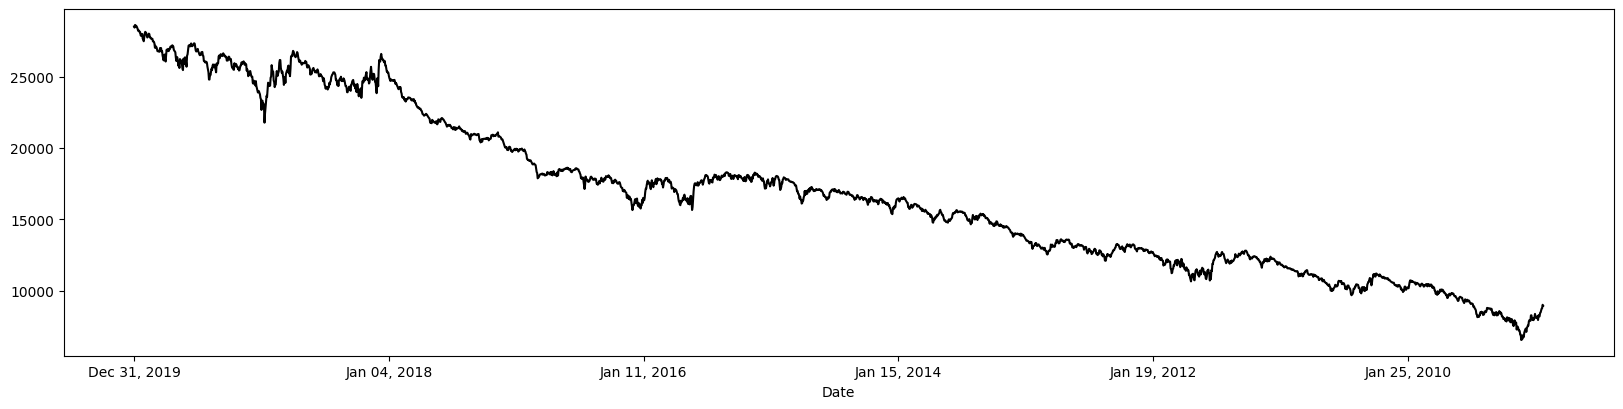

In [11]:
df_dowjones['Price'].plot(figsize = (20,4.5), color = 'black')

Questões:
* Graficamente, a série possui indicativo de estacionariedade?
* É possível identificar períodos com variações atípicas? Se sim, quais?

* ### Testes Estatísticos KPSS e ADF para verificação de estacionariedade.

### Funções Úteis

In [12]:
# TESTE ADF
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

# TESTE KPSS
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        data = kpsstest[0:3], index = ["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)


### Imports Necessários


In [13]:
from statsmodels.tsa.stattools import adfuller, kpss

* TESTE ADF

In [16]:
adf_test(df_dowjones['Price'])

Results of Dickey-Fuller Test:
Test Statistic                   -1.469914
p-value                           0.548339
#Lags Used                       26.000000
Number of Observations Used    2739.000000
Critical Value (1%)              -3.432740
Critical Value (5%)              -2.862596
Critical Value (10%)             -2.567332
dtype: float64


* TESTE KPSS

In [17]:
kpss_test(df_dowjones['Price'])

Results of KPSS Test:
Test Statistic            8.309151
p-value                   0.010000
Lags Used                31.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


C:\Users\p0131335\AppData\Local\Temp\ipykernel_23440\275508419.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


## Interpretando os resultados dos testes ADF e KPSS

**ADF**

Lembre: A hipótese nula do teste ADF é que a série é não estacionária.

**Resposta**:


\\

**KPSS**

Lembre: A hipótese nula do teste KPSS é que a série é estacionária.

**Resposta**:

\\

## Faça e interprete o ACF e PACF

* ## Torne a série estacionária?

Um procedimento comum é tomar as diferenças da série temporal.


* TESTE ADF

## Interprete os resultados dos testes ADF

**TESTE ADF:**

**Resposta**:

\\

---

\\

* ## Examine o gráfico de Autocorrelação da série do índice Dow Jones.

Imports Necessários (acf e pacf)

* **TESTE ADF e KPSS** 

**Nota**

# **Exercício** PIB - (Faça você mesmo)

Acesse a série de código **22100** referente ao PIB Trimestral - Consumo das famílias.

**Dica**: Considere instalar, se necessário, e utilizar a biblioteca DadosAbertosBrasil

Mais informações:
https://www.gustavofurtado.com/dab/index.html


Consulta Códigos:https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries


In [ ]:
# pip install DadosAbertosBrasil

Imports Necessários

Extração da série e correção do dtype para float

Questões:
* Graficamente, a série possui indicativo de estacionariedade?
* É possível identificar períodos com variações atípicas? Se sim, quais?

## Aplique os métodos de Decomposição 

Conclusões sobre tendencia e sazonalidade:

## Aplique o teste ADF e KPSS para identificação de estacionariedade

* Teste ADF


* Teste KPSS

## Interpretando os resultados dos testes ADF e KPSS

**ADF**

Lembre: A hipótese nula do teste ADF é que a série é não estacionária.

**Resposta**:

\\

**KPSS**

Lembre: A hipótese nula do teste KPSS é que a série é estacionária.

**Resposta**:


## Faça e interprete o ACF e PACF

## Se necessário Diferencie e Transforme a série

Gráfico da série

## Interpretando os resultados dos testes ADF e KPSS


* Teste ADF

* Teste KPSS

## Faça e interprete o ACF e PACF

**Questão**: Qual a interpretação dos resultados? Algum fator chamou a sua atenção? Quantas diferenciações foram necessárias para estacionarizar a série?

***OBS***: O teste **ADF**, quando aplicado em séries temporais com **outliers**, pode ter seu **poder** afetado, ou seja, a capacidade do teste em corretamente **identificar** a presença ou ausência de uma raiz unitária pode ser comprometida

# Exercício Série Sazonal - (Faça você mesmo)

Dataset: 1455 (BACEN)

Descrição: Índice volume de vendas no varejo - Total - Brasil

Período a ser examinado: **'2014-01' a '2020-01'**

Extração da série e correção do dtype para float

Gráfico da Série

## Aplique os métodos de Decomposição 

## Aplique o teste ADF e KPSS para identificação de estacionariedade

## Interpretando os resultados dos testes ADF e KPSS

## Faça e interprete o ACF e PACF

## Se necessário Diferencie e Transforme a série

## Aplique o teste ADF e KPSS para identificação de estacionariedade

* Teste ADF

## Faça e interprete o ACF e PACF

Algum fator chama a atenção para este caso? A série não apresenta tendência!
Vamos aplicar diferenças sazonais?